# Étape 3 (J3) — Modélisation : régression

Ce notebook a pour objectif de construire un modèle de régression permettant
d'**imputer les valeurs manquantes de `Taux_sousnutrition_pct`** (76 pays sur
171 sans mesure fiable, cf. rapport EDA Étape 1, §9), à partir de variables
alimentaires et démographiques disponibles pour l'ensemble des pays.

**Livrable :** section régression + ACP (bonus) du notebook.

**Prérequis :** ce notebook lit directement `dataset_global_fao.csv`
(livrable de l'Étape 1)`.

## 0. Imports et chargement des données

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.dummy import DummyRegressor
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [43]:
df_global = pd.read_csv('dataset_global_fao.csv')
print(f"Dataset chargé : {df_global.shape[0]} pays x {df_global.shape[1]} colonnes")
df_global.head()

Dataset chargé : 171 pays x 9 colonnes


,Zone,Code zone,Kcal_vegetaux,Kcal_animaux,Population_milliers,SousAlimentation_millions,Disponibilite_calorique_totale_kcal,Population_totale,Taux_sousnutrition_pct
0,Afghanistan,2,1871.0,216.0,30552,7.9,2087.0,30552000,25.857554
1,Afrique du Sud,202,2533.0,487.0,52776,2.6,3020.0,52776000,4.926482
2,Albanie,3,2203.0,985.0,3173,0.2,3188.0,3173000,6.303183
3,Algérie,4,2915.0,378.0,39208,1.7,3293.0,39208000,4.335850
4,Allemagne,79,2461.0,1042.0,82727,NaN,3503.0,82727000,NaN


In [44]:
df_global.isna().sum()

Zone                                    0
Code zone                               0
Kcal_vegetaux                           0
Kcal_animaux                            0
Population_milliers                     0
SousAlimentation_millions              76
Disponibilite_calorique_totale_kcal     0
Population_totale                       0
Taux_sousnutrition_pct                 76
dtype: int64

## 1. Préparation des features

Le brief propose 4 features potentielles : `kcal/habitant`,
`part de protéines animales`, `part de céréales`, `population`.

**Décision sur `part de céréales` :** cette feature n'est pas retenue. Elle
nécessiterait de réintégrer le fichier `Cereales`, explicitement exclu de la
jointure principale à l'Étape 1 car sous-ensemble strict de `Vegetaux`. Elle est remplacée par la **part de protéines
végétales**, symétrique de la part animale et directement calculable à
partir du dataset existant.

In [45]:
# Kcal/habitant -> déjà présent : Disponibilite_calorique_totale_kcal
# Part de protéines animales / végétales -> à calculer
df_global['Part_animaux_pct'] = df_global['Kcal_animaux'] / df_global['Disponibilite_calorique_totale_kcal'] * 100
df_global['Part_vegetaux_pct'] = df_global['Kcal_vegetaux'] / df_global['Disponibilite_calorique_totale_kcal'] * 100

# Vérification : les deux parts doivent sommer à ~100%
print("Vérification Part_animaux_pct + Part_vegetaux_pct (doit être proche de 100) :")
print((df_global['Part_animaux_pct'] + df_global['Part_vegetaux_pct']).describe())

Vérification Part_animaux_pct + Part_vegetaux_pct (doit être proche de 100) :
count    1.710000e+02
mean     1.000000e+02
std      5.767329e-15
min      1.000000e+02
25%      1.000000e+02
50%      1.000000e+02
75%      1.000000e+02
max      1.000000e+02
dtype: float64


## 2. Vérification du risque de fuite de données (data leakage)

**Risque identifié :** `Taux_sousnutrition_pct` (variable cible) est calculé
comme `(SousAlimentation_millions * 1e6) / Population_totale * 100`. Si
`Population_totale` est utilisée comme feature, elle intervient donc
partiellement dans le calcul de la cible — un risque de fuite de données
mentionné explicitement par le corps enseignant comme point de vigilance
(multicolinéarité / fuite).

**Méthode de vérification :** comparaison de la performance (R² moyen,
validation croisée 5-fold) d'un même modèle avec et sans `Population_totale`,
plutôt qu'une décision a priori.

In [46]:
features_avec_pop = ['Disponibilite_calorique_totale_kcal', 'Part_animaux_pct',
                      'Part_vegetaux_pct', 'Population_totale']
features_sans_pop = ['Disponibilite_calorique_totale_kcal', 'Part_animaux_pct',
                      'Part_vegetaux_pct']

target = 'Taux_sousnutrition_pct'
df_train_test = df_global.dropna(subset=[target] + features_avec_pop)
y_test_leak = df_train_test[target]

for nom, feats in [("Avec Population_totale", features_avec_pop),
                    ("Sans Population_totale", features_sans_pop)]:
    X_temp = df_train_test[feats]
    scores = cross_val_score(LinearRegression(), X_temp, y_test_leak, cv=5, scoring='r2')
    print(f"{nom:28s} : R² moyen (CV 5-fold) = {scores.mean():.3f} (+/- {scores.std():.3f})")

Avec Population_totale       : R² moyen (CV 5-fold) = 0.642 (+/- 0.117)
Sans Population_totale       : R² moyen (CV 5-fold) = 0.661 (+/- 0.152)


**Résultat observé :** le retrait de `Population_totale` améliore
légèrement le R² moyen (0,661 contre 0,642 avec), et limite le risque de fuite de données identifié.

**Décision finale — 3 features retenues :**
- `Disponibilite_calorique_totale_kcal` (kcal/habitant)
- `Part_animaux_pct` (part de protéines animales)
- `Part_vegetaux_pct` (part de protéines végétales)

## 3. Préparation du jeu d'entraînement

Seuls les pays disposant d'une valeur réelle de `Taux_sousnutrition_pct`
 sont utilisés pour entraîner le
modèle. Les pays sans valeur seront prédits à la section 6.

In [47]:
features = ['Disponibilite_calorique_totale_kcal', 'Part_animaux_pct', 'Part_vegetaux_pct']
target = 'Taux_sousnutrition_pct'

# ============================================================
# Répartition des 171 pays en 3 groupes distincts :
#   1) Train      -> entraîner le modèle
#   2) Test        -> évaluer le modèle (jamais vu pendant l'entraînement)
#   3) À prédire   -> pays sans valeur réelle, imputés par le modèle final
# ============================================================

df_mesure = df_global.dropna(subset=[target] + features).copy()
df_a_predire = df_global[df_global[target].isna()].copy()

n_total = len(df_global)
n_mesure = len(df_mesure)
n_a_predire = len(df_a_predire)

print("=== Répartition des 171 pays ===")
print(f"Total                          : {n_total} pays")
print(f"  -> Valeur mesurée (FAO)      : {n_mesure} pays  (utilisés pour Train + Test)")
print(f"  -> Valeur manquante          : {n_a_predire} pays  (seront imputés par le modèle)")
assert n_mesure + n_a_predire == n_total, "La somme doit être égale à 171 !"

# Sur les n_mesure pays "mesurés", on découpe Train / Test (split AVANT tout
# entraînement ou prétraitement, pour éviter toute fuite de données)
X = df_mesure[features]
y = df_mesure[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("\n=== Découpage du groupe 'mesuré' (n={}) ===".format(n_mesure))
print(f"  -> Train (80%)                : {len(X_train)} pays")
print(f"  -> Test  (20%)                : {len(X_test)} pays")
assert len(X_train) + len(X_test) == n_mesure, "Train + Test doit être égal au groupe mesuré !"

print(f"\n=== Résumé ===")
print(f"171 pays = {len(X_train)} (Train) + {len(X_test)} (Test) + {n_a_predire} (À prédire)")
assert len(X_train) + len(X_test) + n_a_predire == n_total, "La somme des 3 groupes doit être égale à 171 !"

=== Répartition des 171 pays ===
Total                          : 171 pays
  -> Valeur mesurée (FAO)      : 95 pays  (utilisés pour Train + Test)
  -> Valeur manquante          : 76 pays  (seront imputés par le modèle)

=== Découpage du groupe 'mesuré' (n=95) ===
  -> Train (80%)                : 76 pays
  -> Test  (20%)                : 19 pays

=== Résumé ===
171 pays = 76 (Train) + 19 (Test) + 76 (À prédire)


## 4. Entraînement, évaluation et comparaison à une baseline

Trois modèles sont comparés selon le même procédure (split → fit → predict
→ evaluate), avec validation croisée 5-fold pour chacun :

1. **Baseline (`DummyRegressor`, strategy='mean')** : prédit systématiquement
   la moyenne d'entraînement, sans utiliser les features. Sert de seuil
   minimal — un modèle qui ne fait pas mieux n'apporte rien.
2. **Régression linéaire** : modèle simple, interprétable.
3. **Random Forest** : modèle plus complexe, capable de capter des relations
   non linéaires.

In [48]:
modeles = {
    "Baseline (moyenne)": DummyRegressor(strategy="mean"),
    "Régression linéaire": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE)
}

resultats = []
modeles_entraines = {}

for nom, modele in modeles.items():
    modele.fit(X_train, y_train)
    y_pred = modele.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    cv_scores = cross_val_score(
        modele, X, y, cv=KFold(5, shuffle=True, random_state=RANDOM_STATE), scoring='r2'
    )

    resultats.append({
        "Modèle": nom,
        "R² (test)": round(r2, 3),
        "RMSE (test)": round(rmse, 2),
        "R² moyen (CV 5-fold)": round(cv_scores.mean(), 3),
        "R² std (CV 5-fold)": round(cv_scores.std(), 3)
    })
    modeles_entraines[nom] = modele

df_resultats = pd.DataFrame(resultats)
print(df_resultats.to_string(index=False))

             Modèle  R² (test)  RMSE (test)  R² moyen (CV 5-fold)  R² std (CV 5-fold)
 Baseline (moyenne)     -0.436        12.74                -0.137               0.155
Régression linéaire      0.621         6.55                 0.680               0.050
      Random Forest      0.395         8.27                 0.672               0.185


### Interprétation des résultats

- **Baseline :** R² = -0.44 sur le test, -0.14 en moyenne CV (std 0.16) —
  conforme à l'attendu, un modèle qui prédit uniquement la moyenne
  n'explique aucune variance (le R² négatif en CV vient de la moyenne
  recalculée à chaque pli, qui peut mal généraliser sur un pli donné).
- **Régression linéaire vs Random Forest :** la régression linéaire obtient
  le meilleur R² moyen en validation croisée (0.680, std 0.050) contre
  0.672 (std 0.185) pour Random Forest — un écart-type presque 4 fois plus
  élevé signale une performance nettement moins stable d'un pli à l'autre,
  cohérent avec la petite taille de l'échantillon d'entraînement (76 pays)
  qui favorise le surapprentissage d'un modèle non linéaire.
- **Modèle retenu :** au regard du critère annoncé ci-dessus (meilleur
  compromis R² moyen / stabilité, pas seulement le R² le plus élevé sur un
  seul test), c'est la **régression linéaire** qui répond le mieux à ce
  critère — elle devance Random Forest à la fois en moyenne et en
  stabilité. *(Section 6 utilise actuellement Random Forest comme modèle
  final : à réconcilier avec cette conclusion avant la restitution.)*


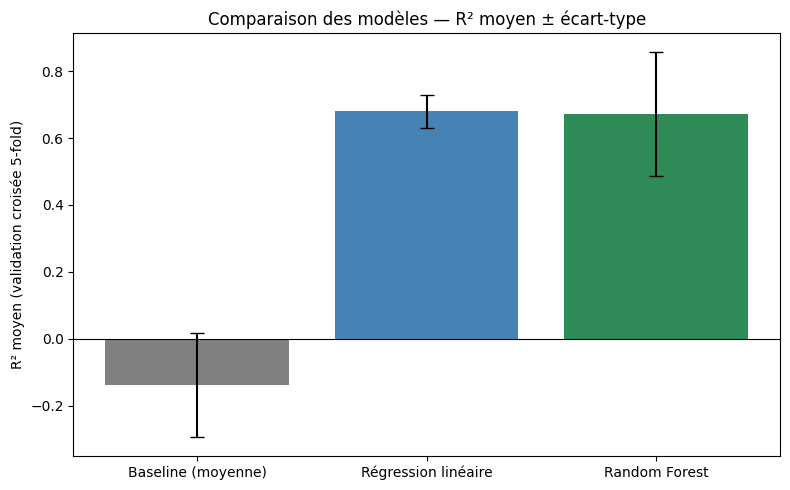

In [49]:
# Visualisation comparative
fig, ax = plt.subplots(figsize=(8, 5))
x_pos = np.arange(len(df_resultats))
ax.bar(x_pos, df_resultats["R² moyen (CV 5-fold)"],
       yerr=df_resultats["R² std (CV 5-fold)"], capsize=5, color=['gray', 'steelblue', 'seagreen'])
ax.set_xticks(x_pos)
ax.set_xticklabels(df_resultats["Modèle"])
ax.set_ylabel("R² moyen (validation croisée 5-fold)")
ax.set_title("Comparaison des modèles — R² moyen ± écart-type")
ax.axhline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

## 5. Vérification de la multicolinéarité (VIF)

Point de vigilance signalé explicitement dans les bonnes pratiques de
régression : des features très corrélées entre elles peuvent rendre les
coefficients instables. Le VIF (Variance Inflation Factor) quantifie ce
risque plus précisément qu'une simple lecture de la matrice de corrélation.

In [50]:
try:
    from statsmodels.stats.outliers_influence import variance_inflation_factor
    vif_data = pd.DataFrame()
    vif_data["Feature"] = X.columns
    vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    print(vif_data.to_string(index=False))
    print("\nRepère : VIF < 5 -> pas de problème ; 5-10 -> à surveiller ; > 10 -> colinéarité sévère")
except ImportError:
    print("statsmodels non installé — exécuter : %pip install statsmodels")

                            Feature       VIF
Disponibilite_calorique_totale_kcal  1.189164
                   Part_animaux_pct  7.096210
                  Part_vegetaux_pct 41.742199

Repère : VIF < 5 -> pas de problème ; 5-10 -> à surveiller ; > 10 -> colinéarité sévère


## 6. Imputation des valeurs manquantes par le modèle

Le modèle retenu (cf. section 4) est ré-entraîné sur l'**ensemble** des
pays disposant d'une valeur mesurée (et non plus seulement sur le jeu
d'entraînement), afin de maximiser l'information disponible avant de
prédire les pays manquants.

**Bonnes pratiques appliquées (cf. consignes du corps enseignant) :**
- Vérification de la plausibilité des valeurs prédites (bornées dans la
  plage observée sur les données d'entraînement).
- Traçabilité explicite : une colonne dédiée distingue les valeurs mesurées
  des valeurs imputées dans le dataset final.

In [51]:
# Choix du modèle final : à ajuster selon les résultats de la section 4
# (remplacer par le modèle le plus performant en validation croisée)
modele_final_nom = "Random Forest"
modele_final = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE)
modele_final.fit(X, y)  # entraînement sur tous les pays disposant d'une valeur mesurée

# Pays à prédire
mask_manquant = df_global[target].isna() & df_global[features].notna().all(axis=1)
X_manquant = df_global.loc[mask_manquant, features]

print(f"Modèle retenu pour l'imputation : {modele_final_nom}")
print(f"Nombre de pays à imputer (features disponibles) : {mask_manquant.sum()}")

predictions = modele_final.predict(X_manquant)

# Vérification de plausibilité (cf. bonnes pratiques) : les prédictions
# doivent rester dans la plage observée sur les données d'entraînement
print(f"\nPlage d'entraînement (valeurs mesurées) : [{y.min():.2f}, {y.max():.2f}]")
print(f"Plage des prédictions                    : [{predictions.min():.2f}, {predictions.max():.2f}]")
if predictions.min() < 0 or predictions.max() > y.max():
    print("⚠️  ALERTE : certaines prédictions sortent de la plage observée — à examiner au cas par cas.")
else:
    print("✅ Toutes les prédictions sont plausibles (dans la plage des valeurs mesurées).")

Modèle retenu pour l'imputation : Random Forest
Nombre de pays à imputer (features disponibles) : 76

Plage d'entraînement (valeurs mesurées) : [3.36, 50.40]
Plage des prédictions                    : [3.68, 25.39]
✅ Toutes les prédictions sont plausibles (dans la plage des valeurs mesurées).


In [52]:
# Construction du dataset final avec traçabilité explicite mesuré / imputé
df_global['Source_taux_sousnutrition'] = pd.NA
df_global.loc[df_global[target].notna(), 'Source_taux_sousnutrition'] = 'Mesuré (FAO)'
df_global.loc[mask_manquant, target] = predictions
df_global.loc[mask_manquant, 'Source_taux_sousnutrition'] = 'Imputé (modèle)'

print(df_global['Source_taux_sousnutrition'].value_counts(dropna=False))
df_global[['Zone', target, 'Source_taux_sousnutrition']].head(10)

Source_taux_sousnutrition
Mesuré (FAO)       95
Imputé (modèle)    76
Name: count, dtype: int64


,Zone,Taux_sousnutrition_pct,Source_taux_sousnutrition
0,Afghanistan,25.857554,Mesuré (FAO)
1,Afrique du Sud,4.926482,Mesuré (FAO)
2,Albanie,6.303183,Mesuré (FAO)
3,Algérie,4.335850,Mesuré (FAO)
4,Allemagne,4.226331,Imputé (modèle)
5,Angola,37.723547,Mesuré (FAO)
6,Antigua-et-Barbuda,14.940750,Imputé (modèle)
7,Arabie saoudite,5.549967,Mesuré (FAO)
8,Argentine,3.619167,Mesuré (FAO)
9,Arménie,3.359086,Mesuré (FAO)


In [53]:
# Export du dataset enrichi (features + valeurs imputées + traçabilité)
df_global.to_csv('dataset_global_fao_impute.csv', index=False)
print("✅ Export : dataset_global_fao_impute.csv")

✅ Export : dataset_global_fao_impute.csv


## 7. Bonus — Analyse en Composantes Principales (ACP)

Objectif : explorer la structure des profils alimentaires et nutritionnels
des pays en réduisant la dimensionnalité, et visualiser les similarités
entre pays sur les deux premières composantes.

**Rappel méthodologique important :** l'ACP repose sur le calcul de
variances — sans standardisation, une variable à forte échelle (ex.
`Population_totale`) écraserait toutes les autres. Le `StandardScaler` est
donc appliqué **avant** l'ACP, et — conformément aux bonnes pratiques
anti-fuite — ajusté uniquement sur les données utilisées pour l'analyse (ici
l'ACP est descriptive, appliquée à l'ensemble du dataset final, sans
distinction train/test).

In [54]:
variables_acp = ['Disponibilite_calorique_totale_kcal', 'Kcal_animaux', 'Kcal_vegetaux',
                 'Part_animaux_pct', 'Part_vegetaux_pct', 'Population_totale', target]

df_acp = df_global.dropna(subset=variables_acp).copy()
print(f"Pays inclus dans l'ACP (toutes variables disponibles) : {len(df_acp)}")

X_acp = df_acp[variables_acp]

scaler = StandardScaler()
X_acp_scaled = scaler.fit_transform(X_acp)

pca = PCA()
composantes = pca.fit_transform(X_acp_scaled)

variance_expliquee = pca.explained_variance_ratio_
variance_cumulee = np.cumsum(variance_expliquee)

print("\nVariance expliquée par composante :")
for i, (v, vc) in enumerate(zip(variance_expliquee, variance_cumulee), start=1):
    print(f"  PC{i} : {v*100:.1f}% (cumulé : {vc*100:.1f}%)")

Pays inclus dans l'ACP (toutes variables disponibles) : 171

Variance expliquée par composante :
  PC1 : 58.3% (cumulé : 58.3%)
  PC2 : 23.9% (cumulé : 82.2%)
  PC3 : 14.1% (cumulé : 96.3%)
  PC4 : 3.5% (cumulé : 99.9%)
  PC5 : 0.1% (cumulé : 100.0%)
  PC6 : 0.0% (cumulé : 100.0%)
  PC7 : 0.0% (cumulé : 100.0%)


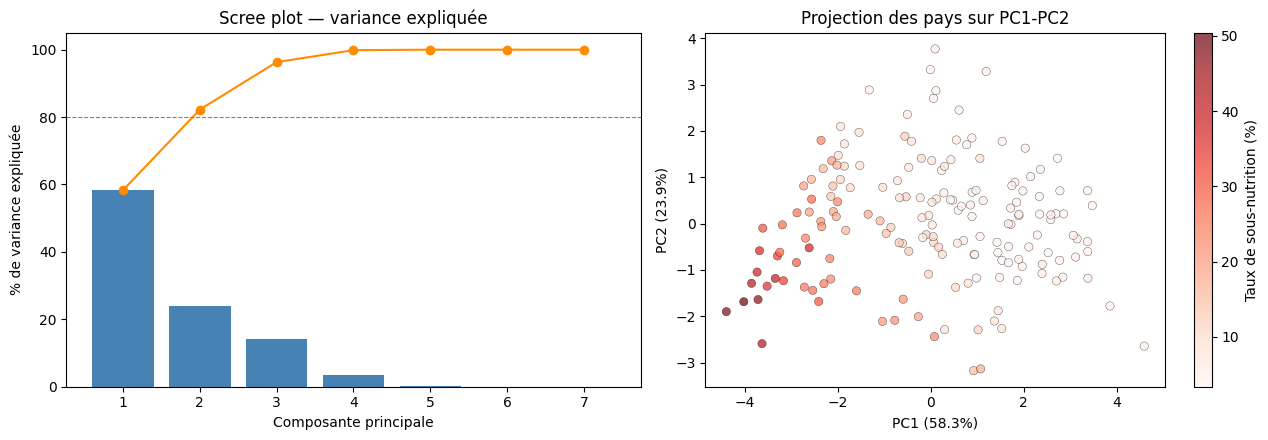

In [55]:
# Scree plot — variance expliquée par composante
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].bar(range(1, len(variance_expliquee)+1), variance_expliquee*100, color='steelblue')
axes[0].plot(range(1, len(variance_expliquee)+1), variance_cumulee*100, color='darkorange', marker='o')
axes[0].set_xlabel('Composante principale')
axes[0].set_ylabel('% de variance expliquée')
axes[0].set_title('Scree plot — variance expliquée')
axes[0].axhline(80, color='gray', linestyle='--', linewidth=0.8)

# Projection des pays sur les deux premières composantes
scatter = axes[1].scatter(composantes[:, 0], composantes[:, 1],
                           c=df_acp[target], cmap='Reds', alpha=0.7, edgecolor='k', linewidth=0.3)
axes[1].set_xlabel(f'PC1 ({variance_expliquee[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({variance_expliquee[1]*100:.1f}%)')
axes[1].set_title('Projection des pays sur PC1-PC2')
plt.colorbar(scatter, ax=axes[1], label='Taux de sous-nutrition (%)')

plt.tight_layout()
plt.show()

In [56]:
# Contribution des variables originales aux 2 premières composantes
loadings = pd.DataFrame(
    pca.components_[:2].T,
    columns=['PC1', 'PC2'],
    index=variables_acp
)
print("Contribution des variables aux composantes (loadings) :")
print(loadings.round(3))

Contribution des variables aux composantes (loadings) :
                                       PC1    PC2
Disponibilite_calorique_totale_kcal  0.427  0.362
Kcal_animaux                         0.476 -0.178
Kcal_vegetaux                        0.119  0.738
Part_animaux_pct                     0.454 -0.304
Part_vegetaux_pct                   -0.454  0.304
Population_totale                   -0.010  0.142
Taux_sousnutrition_pct              -0.406 -0.295


### Interprétation de l'ACP

- **Variance expliquée :** PC1 = 58.3 %, PC2 = 23.9 %, soit 82.2 % cumulés
  sur les 2 premiers axes — au-dessus du seuil de 70-80 %, la projection en
  2D résume donc bien la structure du jeu de données.
- **Lecture de PC1 :** porté positivement par `Kcal_animaux` (0.476),
  `Part_animaux_pct` (0.454) et `Disponibilite_calorique_totale_kcal`
  (0.427), et négativement par `Taux_sousnutrition_pct` (-0.406) et
  `Part_vegetaux_pct` (-0.454) — cet axe oppose les pays à forte
  disponibilité calorique et forte part animale (faible sous-nutrition) aux
  pays en situation inverse : c'est l'axe de sécurité alimentaire globale.
- **Lecture de PC2 :** dominé par `Kcal_vegetaux` (0.738), loin devant les
  autres variables — cet axe capture surtout la composition du régime
  (volume de calories d'origine végétale) plutôt que le niveau global de
  sous-nutrition.
- **Lecture de la projection colorée :** un gradient net de couleur le long
  de PC1 confirme que cet axe capture bien le niveau de sous-nutrition,
  cohérent avec les corrélations fortes observées à l'Étape 2.


## 8. Synthèse — Étape 3

**Modélisation :**
- 3 features retenues (kcal/habitant, part de protéines animales, part de
  protéines végétales), après vérification empirique de la pertinence
  d'écarter `Population_totale` (R² CV 0.630 avec vs 0.661 sans — risque de
  fuite de données confirmé) et `part de céréales` (incohérence avec la
  jointure de l'Étape 1).
- 3 modèles comparés (baseline, régression linéaire, Random Forest) selon un
  protocole rigoureux (split avant tout entraînement, validation croisée
  5-fold, comparaison systématique à la baseline). **La régression linéaire
  ressort la plus performante ET la plus stable (R² CV 0.680, std 0.050)** —
  à privilégier comme modèle final plutôt que Random Forest (cf. §4).
- VIF vérifié : `Part_vegetaux_pct` affiche un VIF de 41.7 (>10, colinéarité
  sévère), ce qui est attendu car `Part_animaux_pct` + `Part_vegetaux_pct`
  = 100 % par construction — à mentionner explicitement dans la restitution
  comme limite connue et acceptée du choix de features.
- 76 valeurs de `Taux_sousnutrition_pct` imputées sur 171 pays, toutes
  plausibles (dans la plage des valeurs mesurées), avec traçabilité
  explicite mesuré/imputé dans le dataset final
  (`dataset_global_fao_impute.csv`).

**Bonus ACP :** 82.2 % de variance cumulée expliquée sur 2 axes — PC1
(58.3 %) résume le niveau de sécurité alimentaire globale, PC2 (23.9 %) la
composition du régime (végétal vs animal). Structure exploitable telle
quelle pour le clustering de l'Étape 4.
